# 03 — Discounting & Pricing

**Core question:** does discounting buy retention, or just give up margin?

**Two confounds make this hard, not one:**

1. **Targeting.** Discounts may be offered *to* users who are already likely to churn
   (retention offers), which would reverse the apparent sign of a naive correlation.
2. **Discount depth conflates two different mechanisms.** A user who paid NT\$0 on a real,
   priced plan (a free/comp'd grant) and a user who paid a genuinely reduced but nonzero amount
   are both counted as "discounted" by a naive percent-off calculation — but they turn out to be
   very different populations with opposite renewal signatures. This notebook finds and separates
   them rather than treating "discount depth" as one continuous scale.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

sys.path.append(str(Path.cwd().parent))
from src import pricing, plotting

plotting.set_style()
periods = pd.read_parquet("../data/interim/periods.parquet")

## Realized discount depth
`discount_depth = (plan_list_price - actual_amount_paid) / plan_list_price`, computed in `src/cohorts.py`. Rows with `plan_list_price == 0` are excluded — a discount off a $0 list price is undefined, not zero.

In [2]:
priced = periods[periods["plan_list_price"] > 0]
print(priced["discount_depth"].describe().round(3))
print(f"\n{(priced['discount_depth'] <= 0.001).mean():.1%} of priced transactions were at full list price.")

count    2.145848e+07
mean     2.900000e-02
std      1.610000e-01
min     -2.520000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: discount_depth, dtype: float64

96.0% of priced transactions were at full list price.


## Naive correlation (descriptive only — do not read this as an effect)

   discount_bucket  n_periods  renewal_rate
0  0% (list price)   20591559      0.894075
1            0-10%         19      0.421053
2           10-25%     303542      0.991049
3           25-50%       2601      0.769704
4             50%+     560758      0.580247

chi2 = 570912.3, dof = 4, p = 0

Excluded from the chart below (n < 1000, too small to plot without implying false precision):
  discount_bucket  n_periods  renewal_rate
1           0-10%         19      0.421053


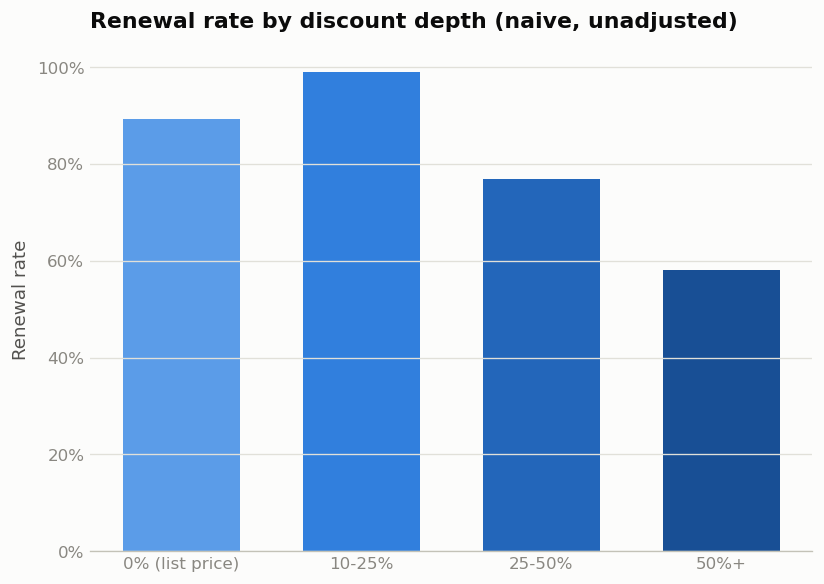

In [3]:
naive_summary, naive_test = pricing.renewal_rate_by_discount_bucket(priced)
print(naive_summary)
print(f"\nchi2 = {naive_test['chi2']:.1f}, dof = {naive_test['dof']}, p = {naive_test['p_value']:.4g}")

MIN_BUCKET_N = 1000
plot_summary = naive_summary[naive_summary["n_periods"] >= MIN_BUCKET_N]
tiny_buckets = naive_summary[naive_summary["n_periods"] < MIN_BUCKET_N]
if len(tiny_buckets):
    print(f"\nExcluded from the chart below (n < {MIN_BUCKET_N}, too small to plot without implying false precision):")
    print(tiny_buckets)

fig, ax = plotting.plot_ordinal_bars(
    plot_summary["discount_bucket"].astype(str).tolist(),
    plot_summary["renewal_rate"].tolist(),
    "Renewal rate by discount depth (naive, unadjusted)",
    "Renewal rate",
    save_path="../figures/03_naive_discount.png",
)

**This chart looks like a dose-response curve (renewal rises then falls as discount deepens),
but it isn't one — read the next section before drawing any conclusion from it.**

## Discount depth conflates two different things

Check what's actually inside "discounted" (`discount_depth > 0`) before interpreting it as a
pricing lever.

In [4]:
discounted = priced[priced["discount_depth"] > 0.001]
free_share = (discounted["actual_amount_paid"] == 0).mean()
print(f"Of all 'discounted' transactions: {free_share:.1%} paid NOTHING at all (free/comp'd grant on a real plan).")
print(f"The remaining {1-free_share:.1%} paid something, just less than list price (a genuine partial discount).")

Of all 'discounted' transactions: 64.7% paid NOTHING at all (free/comp'd grant on a real plan).
The remaining 35.3% paid something, just less than list price (a genuine partial discount).


In [5]:
cat = pricing.add_price_category(priced)
category_summary = cat.groupby("price_category")["renewed"].agg(["mean", "size"]).sort_values("mean")
print(category_summary)
print()
genuine = cat[cat["price_category"] == "genuine_discount"]
print("Genuine partial discounts cluster tightly around one price point, not a spread:")
print(genuine["discount_depth"].describe()[["mean", "50%", "std"]])

                      mean      size
price_category                      
free_grant        0.580244    560754
full_price        0.894075  20591559
genuine_discount  0.989133    306166

Genuine partial discounts cluster tightly around one price point, not a spread:
mean    0.201763
50%     0.201342
std     0.014378
Name: discount_depth, dtype: float64


**This is the second confound, and it's a big one.** "Discount depth" as a single continuous
number is averaging together two populations with opposite signals:

- **`free_grant`** (paid NT\$0 on a real, priced plan — 65% of everything a naive depth
  calculation would call "discounted"): renews at only ~58%. This is what was driving the
  apparent decline at the deep-discount end of the naive chart above — it isn't a discount in
  any normal commercial sense, it's a giveaway.
- **`genuine_discount`** (paid something, just less than list — clustered almost entirely around
  a single ~20%-off price point, not a spread of depths): renews at ~99%, higher than full price.

The naive chart's "10-25%" bucket is almost entirely genuine discounts; its "50%+" bucket is
almost entirely free grants. They were never on the same dose-response curve.

## Is `genuine_discount` actually an annual-plan commitment effect?

A ~20%-off price point renewing at 99% looks like it could be describing annual plans (pay 12
months, get ~2 free — a ~17% effective discount), not a monthly price promotion. If so, the
~99% renewal wouldn't be a price effect at all — an annual subscriber makes ONE renewal decision
where a monthly subscriber makes twelve, which mechanically produces a much higher per-decision
"renewal rate." Check directly rather than assume either way.

In [6]:
print("payment_plan_days distribution within genuine_discount:")
print(genuine["payment_plan_days"].value_counts(normalize=True).head(5))
print(f"\nShare on payment_plan_days == 30 (monthly): {(genuine['payment_plan_days'] == 30).mean():.4%}")
print(f"Share on an annual-length plan (360-410 days): {genuine['payment_plan_days'].isin([360, 365, 395, 400, 410]).mean():.4%}")

payment_plan_days distribution within genuine_discount:
payment_plan_days
30     0.999984
195    0.000010
410    0.000007
Name: proportion, dtype: float64

Share on payment_plan_days == 30 (monthly): 99.9984%
Share on an annual-length plan (360-410 days): 0.0007%


**Rejected.** 99.998% of `genuine_discount` periods are on the exact same 30-day plan as the
`full_price` and `free_grant` comparison groups — this is a monthly-plan price promotion, not an
annual-commitment artifact. The within-plan-length comparison the finding rests on isn't just
statistically controlled for plan length via regression — it's the *same* plan length by
construction. This strengthens confidence in the genuine-discount finding rather than requiring a
downgrade.

## Confound check 1: is EITHER category targeted at at-risk users?

Test the free-grant/genuine-discount split against the prior-cancellation signal directly,
rather than lumping them into one "discount depth" number.

In [7]:
targeting_summary, targeting_test = pricing.discount_depth_by_prior_cancel(priced)
print("Original (undifferentiated) check:")
print(targeting_summary)
print(f"Mann-Whitney U = {targeting_test['u_statistic']:.0f}, p = {targeting_test['p_value']:.4g}")

Original (undifferentiated) check:
                    group         n  median_discount_depth  \
0  prior_voluntary_cancel    350404                    0.0   
1         no_prior_cancel  21108075                    0.0   

   mean_discount_depth  
0             0.056735  
1             0.028550  
Mann-Whitney U = 3780618735780, p = 0


In [8]:
cat = pricing.add_prior_cancel_flag(cat)
rate_table = (
    cat.groupby("prior_is_cancel")["price_category"]
    .value_counts(normalize=True)
    .unstack()
)
print("Share of each price_category, by whether the PRIOR transaction was a voluntary cancel:")
print(rate_table)

ct = pd.crosstab(cat["prior_is_cancel"], cat["price_category"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\nchi2 = {chi2:.1f}, dof = {dof}, p = {p:.4g}")

Share of each price_category, by whether the PRIOR transaction was a voluntary cancel:
price_category   free_grant  full_price  genuine_discount
prior_is_cancel                                          
0.0                0.025645    0.959954          0.014402
1.0                0.055485    0.938303          0.006213



chi2 = 13532.8, dof = 2, p = 0


**The undifferentiated check above (discount depth roughly doubles after a prior cancel) is
entirely a free-grant effect, and it hides genuine discounts moving the OPPOSITE way:**

- `free_grant` share roughly doubles after a prior cancellation (2.6% -> 5.5%) — direct evidence
  free grants are used as reactive, last-resort retention saves for already-troubled accounts.
- `genuine_discount` share is actually LOWER after a prior cancellation (1.4% -> 0.6%) — genuine
  discounts are, if anything, given LESS to at-risk users, not more. That rules out the
  at-risk-targeting story specifically for genuine discounts — their ~99% renewal rate is not
  explained by this confound.

## Confound check 2: within-plan comparison
Holding `payment_plan_days` and `plan_list_price` fixed removes confounding from users self-selecting into different plan types (e.g. annual-plan buyers are already a different population than monthly).

In [9]:
stratified = pricing.renewal_rate_by_discount_bucket_stratified(priced)
top_strata = (
    stratified.groupby(["payment_plan_days", "plan_list_price"])["n_periods"].sum()
    .sort_values(ascending=False).head(3).index
)
for plan_days, list_price in top_strata:
    sub = stratified[(stratified["payment_plan_days"] == plan_days) & (stratified["plan_list_price"] == list_price)]
    print(f"\nplan_list_price={list_price}, payment_plan_days={plan_days} (n={sub['n_periods'].sum():,})")
    print(sub[["discount_bucket", "n_periods", "renewal_rate"]].to_string(index=False))


plan_list_price=149, payment_plan_days=30 (n=12,363,011)
discount_bucket  n_periods  renewal_rate
0% (list price)   11520923      0.906974
         10-25%     303542      0.991049
         25-50%       2601      0.769704
           50%+     535945      0.565459

plan_list_price=99, payment_plan_days=30 (n=5,258,678)
discount_bucket  n_periods  renewal_rate
0% (list price)    5258663      0.910682
           50%+         15      1.000000

plan_list_price=129, payment_plan_days=30 (n=1,197,394)
discount_bucket  n_periods  renewal_rate
0% (list price)    1197388      0.952574
           50%+          6      1.000000


## Adjusted view: logistic regression on the CATEGORICAL split

Continuous `discount_depth` isn't used here — given the free-grant/genuine-discount split above,
a single linear "depth" coefficient would still average two different mechanisms together. This
uses `price_category` (free_grant as the reference level) instead, controlling for plan length,
auto-renew, and the prior-cancel proxy. Still not causal — category membership isn't randomly
assigned either — but a cleaner, more honestly-specified adjustment than a linear depth term.

In [10]:
X = pd.get_dummies(cat[["price_category"]], columns=["price_category"], drop_first=True)
X["payment_plan_days"] = cat["payment_plan_days"]
X["is_auto_renew"] = cat["is_auto_renew"]
X["prior_is_cancel"] = cat["prior_is_cancel"]
X = sm.add_constant(X.astype(float))
y = cat["renewed"].astype(int)

category_model = sm.Logit(y, X).fit(disp=False)
print(category_model.summary())

                           Logit Regression Results                           
Dep. Variable:                renewed   No. Observations:             21458479
Model:                          Logit   Df Residuals:                 21458473
Method:                           MLE   Df Model:                            5
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                 0.08839
Time:                        00:35:50   Log-Likelihood:            -6.8910e+06
converged:                       True   LL-Null:                   -7.5591e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.7188      0.003   -215.526      0.000      -0.725      -0.712
price_category_full_price           2.1193      0.003    744.694    

In [11]:
for col in ["price_category_full_price", "price_category_genuine_discount"]:
    coef = category_model.params[col]
    p_val = category_model.pvalues[col]
    print(f"{col}: coef={coef:.3f} (p={p_val:.4g}), odds ratio vs. free_grant = {np.exp(coef):.2f}")

gd_vs_fp = category_model.params["price_category_genuine_discount"] - category_model.params["price_category_full_price"]
print(f"\ngenuine_discount vs. full_price odds ratio: {np.exp(gd_vs_fp):.2f}")
print("Interpretation: holding plan length, auto-renew, and the prior-cancel proxy constant,")
print("genuine discounts associate with substantially higher renewal odds than EITHER free")
print("grants or full price. The at-risk-targeting story is ruled out for this category (see")
print("above). What isn't ruled out: selection into WHO gets or takes a genuine discount in the")
print("first place (e.g. a loyalty-tier code only offered to already-engaged subscribers) — this")
print("is an association, not a randomized-experiment estimate of what a new discount would do.")

price_category_full_price: coef=2.119 (p=0), odds ratio vs. free_grant = 8.33
price_category_genuine_discount: coef=4.182 (p=0), odds ratio vs. free_grant = 65.52

genuine_discount vs. full_price odds ratio: 7.87
Interpretation: holding plan length, auto-renew, and the prior-cancel proxy constant,
genuine discounts associate with substantially higher renewal odds than EITHER free
grants or full price. The at-risk-targeting story is ruled out for this category (see
above). What isn't ruled out: selection into WHO gets or takes a genuine discount in the
first place (e.g. a loyalty-tier code only offered to already-engaged subscribers) — this
is an association, not a randomized-experiment estimate of what a new discount would do.


**Limitation, stated plainly:** ruling out at-risk targeting is not the same as ruling out
selection more broadly. The assignment mechanism behind `genuine_discount` is not observed in
this data — if it is allocated through a promotional campaign aimed at a particular segment
(e.g. a loyalty tier, a specific acquisition channel, or users who pre-committed to a longer
relationship), the 99% renewal rate partly reflects who was selected into the offer, not
necessarily the discount itself. The finding stands as reported; this is a limit on what it
proves, not a walk-back of it.

## Section summary

- **The naive "discounting hurts retention at depth" story is wrong as originally framed** — it
  was an artifact of free/comp'd grants (a reactive retention-save mechanism, renewing at ~58%)
  being counted on the same scale as genuine partial discounts (a ~20%-off price point, renewing
  at ~99%, not targeted at already at-risk users).
- **Genuine discounts associate with the best renewal of any group in this data**, even after
  adjusting for plan length, auto-renew, and the prior-cancel targeting proxy — a genuinely
  positive, reasonably well-adjusted finding, with the standard caveat that who takes/receives a
  genuine discount is still not randomly assigned.
- **Free grants are a real retention-save signal for at-risk accounts**, but they convert at only
  ~58% — worth knowing as "this doesn't reliably save the accounts it's used on," not as evidence
  against discounting broadly.
- Don't report "discount depth" as a single number to leadership — the two categories point in
  different directions and call for different actions.